# DDA - Label-Free

This tutorial demonstrates how to analyze label-free quantification (LFQ) data from data-dependent acquisition (DDA) using the `msmu` package.

## Data Preparation

Original dataset is from [PXD012986](https://www.ebi.ac.uk/pride/archive/projects/PXD012986) (Uszkoreit _et al_., 2022) and search was performed with [`Sage` v0.14.7](https://github.com/lazear/sage/tree/v0.14.7).

For demonstration purposes, the example dataset was reduced to six samples and a total of 5,000 PSMs.


In [1]:
base_dir = "https://raw.githubusercontent.com/bertis-informatics/msmu/refs/heads/dev/data/sage_lfq"
sage_idents = f"{base_dir}/sage/results.sage.tsv"
sage_quants = f"{base_dir}/sage/lfq.tsv"
sdrf = f"{base_dir}/meta.sdrf.tsv"

## Load Required Packages

> If you haven't installed the `msmu` package yet, please follow the [installation guide](../../installation/).


In [2]:
import msmu as mm
import plotly.io as pio

pio.renderers.default = "png"

## Read Data

You can read data from various proteomics software outputs. Below are examples for `Sage`, `MaxQuant`, and `FragPipe` formats.

For this tutorial, we will use the `Sage` output as an example.

`read_sage()` function reads the `Sage` output files (`lfq.tsv`, `results.sage.tsv`) and creates modalities at MuData object.


In [3]:
# Sage format
mdata = mm.read_sage(
    identification_file=sage_idents,
    quantification_file=sage_quants,
    label="label_free",
    sdrf_file=sdrf,
)

# # MaxQuant format
# mdata = mm.read_maxquant(
#     identification_file="path_to_maxquant_output",
#     sdrf_file=sdrf,
#     label="label_free",
#     acquisition="dda",
# )

# # FragPipe format
# mdata = mm.read_fragpipe(
#     identification_file="path_to_fragpipe_output",
#     sdrf_file=sdrf,
#     label="label_free",
#     acquisition="dda",
# )

In [4]:
mdata

MuData object with n_obs × n_vars = 6 × 8233
  obs:	'source_name', 'characteristics_organism', 'characteristics_organism_part', 'characteristics_cell_line', 'characteristics_cell_type', 'characteristics_cellosaurus_accession', 'characteristics_cellosaurus_name', 'characteristics_disease', 'characteristics_biological_replicate', 'assay_name', 'technology_type', 'comment_proteomexchange_accession_number', 'comment_proteomics_data_acquisition_method', 'comment_data_file', 'comment_fraction_identifier', 'comment_technical_replicate', 'comment_label', 'comment_instrument', 'comment_cleavage_agent_details', 'factor_value_condition'
  uns:	'sdrf', '_cmd'
  2 modalities
    psm:	6 x 4655
      obs:	'source_name', 'characteristics_organism', 'characteristics_organism_part', 'characteristics_cell_line', 'characteristics_cell_type', 'characteristics_cellosaurus_accession', 'characteristics_cellosaurus_name', 'characteristics_disease', 'characteristics_biological_replicate', 'assay_name', 'technology_type', 'comment_proteomexchange_accession_number', 'comment_proteomics_data_acquisition_method', 'comment_data_file', 'comment_fraction_identifier', 'comment_technical_replicate', 'comment_label', 'comment_instrument', 'comment_cleavage_agent_details', 'factor_value_condition'
      var:	'proteins', 'peptide', 'stripped_peptide', 'filename', 'scan_num', 'charge', 'peptide_length', 'expmass', 'calcmass', 'rt', 'missed_cleavages', 'semi_enzymatic', 'contaminant', 'PEP', 'score', 'q_value', 'decoy'
      uns:	'level', 'search_engine', 'quantification', 'label', 'acquisition', 'identification_file', 'quantification_file', 'decoy', 'sdrf'
      varm:	'search_result'
    peptide:	6 x 3578
      obs:	'source_name', 'characteristics_organism', 'characteristics_organism_part', 'characteristics_cell_line', 'characteristics_cell_type', 'characteristics_cellosaurus_accession', 'characteristics_cellosaurus_name', 'characteristics_disease', 'characteristics_biological_replicate', 'assay_name', 'technology_type', 'comment_proteomexchange_accession_number', 'comment_proteomics_data_acquisition_method', 'comment_data_file', 'comment_fraction_identifier', 'comment_technical_replicate', 'comment_label', 'comment_instrument', 'comment_cleavage_agent_details', 'factor_value_condition'
      uns:	'level', 'sdrf'

### Saving Raw MuData Object

After reading the search output, saving the MuData object as an `h5mu` file is recommended for future use.


In [5]:
mdata["psm"].var

,proteins,peptide,stripped_peptide,filename,scan_num,charge,peptide_length,expmass,calcmass,rt,missed_cleavages,semi_enzymatic,contaminant,PEP,score,q_value,decoy
QExHF04048.35738,D3Z2H2;D3Z2H7;D3Z7H6;E9Q8Z4;E9Q8Z5;E9Q8Z6;E9Q8...,AAALVLQTIWGYK,AAALVLQTIWGYK,QExHF04048,35738,3,13,1432.80710,1432.80790,96.601020,0,0,0,4.910910e-11,25.524469,0.000003,0
QExHF04028.32557,A0A286YDI8;G3X972,GQVPPLVTTNFLVK,GQVPPLVTTNFLVK,QExHF04028,32557,2,14,1511.87290,1511.87110,88.938370,0,0,0,1.174559e-12,39.376776,0.000003,0
QExHF04036.26748,Q61166,NIELIC[+57.0215]QENEGENDPVLQR,NIELICQENEGENDPVLQR,QExHF04036,26748,2,19,2269.07100,2269.06450,74.547970,0,0,0,2.329968e-69,71.549478,0.000003,0
QExHF04028.17723,A0A0A6YY12;Q3U9G9,LGAFDLK,LGAFDLK,QExHF04028,17723,2,7,762.42847,762.42755,52.822567,0,0,0,3.912462e-03,30.037241,0.000177,0
QExHF04036.42576,Q8BMJ2,FSEAEHWLDYFPPLAVQDLK,FSEAEHWLDYFPPLAVQDLK,QExHF04036,42576,3,20,2404.17940,2404.17360,113.637380,0,0,0,1.198105e-33,51.200146,0.000003,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
QExHF04038.39796,P20108,DYGVLLESAGIALR,DYGVLLESAGIALR,QExHF04038,39796,2,14,1475.80030,1475.79850,106.520210,0,0,0,2.429070e-71,53.174612,0.000003,0
QExHF04048.44300,Q9JHU4,GIFEALRPLETLPVEGLIR,GIFEALRPLETLPVEGLIR,QExHF04048,44300,3,19,2122.21920,2122.21500,117.822130,0,0,0,3.890935e-17,69.300551,0.000003,0
QExHF04048.17559,P56480,IPVGPETLGR,IPVGPETLGR,QExHF04048,17559,2,10,1037.58740,1037.58690,52.281140,0,0,0,4.175938e-30,43.566094,0.000003,0
QExHF04026.48861,D3YZ68;D3Z3I8;P10126;P62631,NM[+15.9949]ITGTSQADC[+57.0215]AVLIVAAGVGEFEAGISK,NMITGTSQADCAVLIVAAGVGEFEAGISK,QExHF04026,48861,3,29,2925.46500,2924.42550,130.408460,0,0,0,9.746395e-24,54.283167,0.000003,0


In [6]:
mdata.write_h5mu("dda_lfq_PXD012986_raw.h5mu")

## Handling PSM level

### Filtering - PSM

You can filter the data based on the column values, such as q-value.
You can also filter the data based on string containment, which can be useful for removing contaminants or decoys.

Filtering is split into two steps: first, you mark a filter condition using `mm.pp.add_filter()`, and then you apply the filter using `mm.pp.apply_filter()`.

Here, we keep protein groups with q-value < 0.01 and remove contaminants (protein IDs containing "contam\_").


In [7]:
mdata = mm.pp.add_filter(mdata, modality="psm", column="q_value", keep="lt", value=0.01)
mdata = mm.pp.add_filter(mdata, modality="psm", column="proteins", keep="not_contains", value="contam_")
mdata = mm.pp.apply_filter(mdata, modality="psm", on="var")

mdata

INFO - Applying var filters for psm: ['q_value_lt_0.01', 'proteins_not_contains_contam_']


MuData object with n_obs × n_vars = 6 × 7837
  obs:	'source_name', 'characteristics_organism', 'characteristics_organism_part', 'characteristics_cell_line', 'characteristics_cell_type', 'characteristics_cellosaurus_accession', 'characteristics_cellosaurus_name', 'characteristics_disease', 'characteristics_biological_replicate', 'assay_name', 'technology_type', 'comment_proteomexchange_accession_number', 'comment_proteomics_data_acquisition_method', 'comment_data_file', 'comment_fraction_identifier', 'comment_technical_replicate', 'comment_label', 'comment_instrument', 'comment_cleavage_agent_details', 'factor_value_condition'
  uns:	'sdrf', '_cmd'
  2 modalities
    psm:	6 x 4259
      obs:	'source_name', 'characteristics_organism', 'characteristics_organism_part', 'characteristics_cell_line', 'characteristics_cell_type', 'characteristics_cellosaurus_accession', 'characteristics_cellosaurus_name', 'characteristics_disease', 'characteristics_biological_replicate', 'assay_name', 'technology_type', 'comment_proteomexchange_accession_number', 'comment_proteomics_data_acquisition_method', 'comment_data_file', 'comment_fraction_identifier', 'comment_technical_replicate', 'comment_label', 'comment_instrument', 'comment_cleavage_agent_details', 'factor_value_condition'
      var:	'proteins', 'peptide', 'stripped_peptide', 'filename', 'scan_num', 'charge', 'peptide_length', 'expmass', 'calcmass', 'rt', 'missed_cleavages', 'semi_enzymatic', 'contaminant', 'PEP', 'score', 'q_value', 'decoy'
      uns:	'level', 'search_engine', 'quantification', 'label', 'acquisition', 'identification_file', 'quantification_file', 'decoy', 'sdrf', 'filter', 'decoy_filter'
      varm:	'search_result', 'filter'
    peptide:	6 x 3578
      obs:	'source_name', 'characteristics_organism', 'characteristics_organism_part', 'characteristics_cell_line', 'characteristics_cell_type', 'characteristics_cellosaurus_accession', 'characteristics_cellosaurus_name', 'characteristics_disease', 'characteristics_biological_replicate', 'assay_name', 'technology_type', 'comment_proteomexchange_accession_number', 'comment_proteomics_data_acquisition_method', 'comment_data_file', 'comment_fraction_identifier', 'comment_technical_replicate', 'comment_label', 'comment_instrument', 'comment_cleavage_agent_details', 'factor_value_condition'
      uns:	'level', 'sdrf'

## Handling peptide level

### Summarization - peptide

You can summarize psm-level data to peptide-level data using the `mm.pp.to_peptide()` function.


In [8]:
mdata = mm.pp.to_peptide(mdata)

INFO - Peptide-level identifications: 3634 (3615 at 1% FDR)
INFO - Using existing peptide quantification data.


### Filtering - peptide


In [9]:
mdata = mm.pp.add_filter(mdata, modality="peptide", column="q_value", keep="lt", value=0.01)
mdata = mm.pp.apply_filter(mdata, modality="peptide", on="var")

mdata

INFO - Applying var filters for peptide: ['q_value_lt_0.01']


MuData object with n_obs × n_vars = 6 × 7874
  obs:	'source_name', 'characteristics_organism', 'characteristics_organism_part', 'characteristics_cell_line', 'characteristics_cell_type', 'characteristics_cellosaurus_accession', 'characteristics_cellosaurus_name', 'characteristics_disease', 'characteristics_biological_replicate', 'assay_name', 'technology_type', 'comment_proteomexchange_accession_number', 'comment_proteomics_data_acquisition_method', 'comment_data_file', 'comment_fraction_identifier', 'comment_technical_replicate', 'comment_label', 'comment_instrument', 'comment_cleavage_agent_details', 'factor_value_condition'
  uns:	'sdrf', '_cmd'
  2 modalities
    psm:	6 x 4259
      obs:	'source_name', 'characteristics_organism', 'characteristics_organism_part', 'characteristics_cell_line', 'characteristics_cell_type', 'characteristics_cellosaurus_accession', 'characteristics_cellosaurus_name', 'characteristics_disease', 'characteristics_biological_replicate', 'assay_name', 'technology_type', 'comment_proteomexchange_accession_number', 'comment_proteomics_data_acquisition_method', 'comment_data_file', 'comment_fraction_identifier', 'comment_technical_replicate', 'comment_label', 'comment_instrument', 'comment_cleavage_agent_details', 'factor_value_condition'
      var:	'proteins', 'peptide', 'stripped_peptide', 'filename', 'scan_num', 'charge', 'peptide_length', 'expmass', 'calcmass', 'rt', 'missed_cleavages', 'semi_enzymatic', 'contaminant', 'PEP', 'score', 'q_value', 'decoy'
      uns:	'level', 'search_engine', 'quantification', 'label', 'acquisition', 'identification_file', 'quantification_file', 'decoy', 'sdrf', 'filter', 'decoy_filter'
      varm:	'search_result', 'filter'
    peptide:	6 x 3615
      var:	'peptide', 'proteins', 'stripped_peptide', 'count_psm', 'PEP', 'q_value'
      uns:	'level', 'decoy', 'filter', 'decoy_filter'
      varm:	'filter'

### Normalization

Here, we log2 transform and normalize the data at the peptide level.

Median centering normalization is applied using `mm.pp.normalize()` function.


In [10]:
mdata = mm.pp.log2_transform(mdata, modality="peptide")
mdata = mm.pp.normalize(mdata, modality="peptide", method="median")

### Protein inference

You can infer protein-level data from peptide-level data using the `mm.pp.infer_protein()` function.


In [11]:
mdata = mm.pp.infer_protein(mdata)

INFO - Starting protein inference
INFO - Initial proteins: 3651
INFO - Removed indistinguishable: 1586
INFO - Removed subsettable: 539
INFO - Removed subsumable: 2
INFO - Total protein groups: 1524


## Handling protein level

### Summarization - protein

You can summarize peptide-level data to protein-level data using the `mm.pp.to_protein()` function.

As default, top 3 peptides within protein group can be used for protein group quantification aggregation. If top_n is None, all peptides will be used.


In [12]:
mdata = mm.pp.to_protein(mdata, top_n=3, rank_method="median_intensity")

INFO - Applying var filters for peptide: ['q_value_lt_0.01', 'peptide_type_eq_unique']
INFO - Protein-level identifications: 1489 (1463 at 1% FDR)


### Filtering - protein


In [13]:
mdata = mm.pp.add_filter(mdata, modality="protein", column="q_value", keep="lt", value=0.01)
mdata = mm.pp.apply_filter(mdata, modality="protein", on="var")

mdata

INFO - Applying var filters for protein: ['q_value_lt_0.01']


MuData object with n_obs × n_vars = 6 × 9337
  obs:	'source_name', 'characteristics_organism', 'characteristics_organism_part', 'characteristics_cell_line', 'characteristics_cell_type', 'characteristics_cellosaurus_accession', 'characteristics_cellosaurus_name', 'characteristics_disease', 'characteristics_biological_replicate', 'assay_name', 'technology_type', 'comment_proteomexchange_accession_number', 'comment_proteomics_data_acquisition_method', 'comment_data_file', 'comment_fraction_identifier', 'comment_technical_replicate', 'comment_label', 'comment_instrument', 'comment_cleavage_agent_details', 'factor_value_condition'
  uns:	'sdrf', '_cmd'
  3 modalities
    psm:	6 x 4259
      obs:	'source_name', 'characteristics_organism', 'characteristics_organism_part', 'characteristics_cell_line', 'characteristics_cell_type', 'characteristics_cellosaurus_accession', 'characteristics_cellosaurus_name', 'characteristics_disease', 'characteristics_biological_replicate', 'assay_name', 'technology_type', 'comment_proteomexchange_accession_number', 'comment_proteomics_data_acquisition_method', 'comment_data_file', 'comment_fraction_identifier', 'comment_technical_replicate', 'comment_label', 'comment_instrument', 'comment_cleavage_agent_details', 'factor_value_condition'
      var:	'proteins', 'peptide', 'stripped_peptide', 'filename', 'scan_num', 'charge', 'peptide_length', 'expmass', 'calcmass', 'rt', 'missed_cleavages', 'semi_enzymatic', 'contaminant', 'PEP', 'score', 'q_value', 'decoy'
      uns:	'level', 'search_engine', 'quantification', 'label', 'acquisition', 'identification_file', 'quantification_file', 'decoy', 'sdrf', 'filter', 'decoy_filter'
      varm:	'search_result', 'filter'
    peptide:	6 x 3615
      obs:	'source_name', 'characteristics_organism', 'characteristics_organism_part', 'characteristics_cell_line', 'characteristics_cell_type', 'characteristics_cellosaurus_accession', 'characteristics_cellosaurus_name', 'characteristics_disease', 'characteristics_biological_replicate', 'assay_name', 'technology_type', 'comment_proteomexchange_accession_number', 'comment_proteomics_data_acquisition_method', 'comment_data_file', 'comment_fraction_identifier', 'comment_technical_replicate', 'comment_label', 'comment_instrument', 'comment_cleavage_agent_details', 'factor_value_condition'
      var:	'peptide', 'proteins', 'stripped_peptide', 'count_psm', 'PEP', 'q_value', 'protein_group', 'peptide_type'
      uns:	'level', 'decoy', 'filter', 'decoy_filter'
      varm:	'filter'
    protein:	6 x 1463
      obs:	'source_name', 'characteristics_organism', 'characteristics_organism_part', 'characteristics_cell_line', 'characteristics_cell_type', 'characteristics_cellosaurus_accession', 'characteristics_cellosaurus_name', 'characteristics_disease', 'characteristics_biological_replicate', 'assay_name', 'technology_type', 'comment_proteomexchange_accession_number', 'comment_proteomics_data_acquisition_method', 'comment_data_file', 'comment_fraction_identifier', 'comment_technical_replicate', 'comment_label', 'comment_instrument', 'comment_cleavage_agent_details', 'factor_value_condition'
      var:	'count_psm', 'count_stripped_peptide', 'PEP', 'q_value'
      uns:	'level', 'decoy', 'filter', 'decoy_filter'
      varm:	'filter'

## Visualization

### ID plot


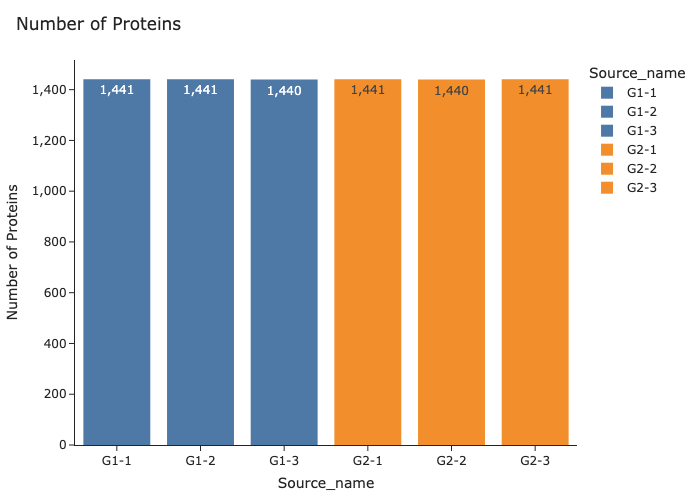

In [14]:
mm.pl.plot_id(mdata, modality="protein", colorby="factor_value_condition")

### Intensity distribution plot


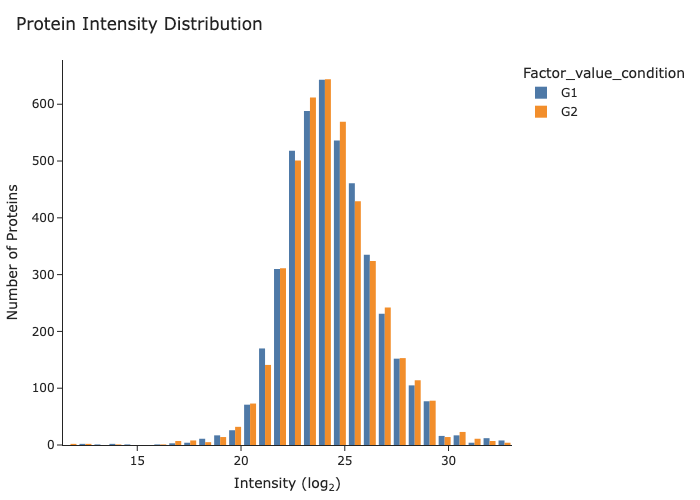

In [15]:
mm.pl.plot_intensity(mdata, modality="protein", groupby="factor_value_condition")

## Saving Processed MuData Object

You can save MuData object into an `h5mu` file.
This allows you to easily reload the processed data in future sessions without repeating the entire analysis pipeline.


In [16]:
mdata.write_h5mu("dda_lfq_PXD012986.h5mu")

## Citation

> Uszkoreit, J., Barkovits, K., Pacharra, S., Pfeiffer, K., Steinbach, S., Marcus, K., & Eisenacher, M. (2022). Dataset containing physiological amounts of spike-in proteins into murine C2C12 background as a ground truth quantitative LC-MS/MS reference. _Data in Brief_, 43, 108435.

> Lazear, M. R. (2023). Sage: an open-source tool for fast proteomics searching and quantification at scale. _Journal of Proteome Research_, 22(11), 3652-3659.
